В цьому домашньому завданні ми з вами побудуємо повноцінне ML-рішення реальної ML-задачі. Ви вже маєте всі знання, які для цього потрібні. Дотримуйтесь інструкцій, та користуйтесь матеріалами лекцій, аби виконувати завдання. Тут інструкції будуть детальні, а в подільших завданнях - будуть ставати все менш детальними, аби ви вже починали самостійно структурувати ML-проєкт і до кінця курсу для вас розвʼязати будь-яку ML–задачу було eazy-breezy.

## Dataset

Будемо працювати з набором даних `cars.csv`, який описує автомобілі і їх ціну у індійських рупіях :) Мета - передбачити ціну авто за його характеристиками. Опис набору даних:

| Назва рядка            | Опис                                                                                                                                                 |
|------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------|
| Car_ID                 | Унікальний ідентифікатор для кожного оголошення про автомобіль.                                                                                         |
| Brand                  | Бренд або виробник автомобіля (наприклад, Toyota, Honda, Ford тощо).                                                                                     |
| Model                  | Модель автомобіля (наприклад, Camry, Civic, Mustang тощо).                                                                                               |
| Year                   | Рік виготовлення автомобіля.                                                                                                                            |
| Kilometers_Driven      | Загальний пробіг автомобіля у кілометрах.                                                                                                               |
| Fuel_Type              | Тип палива, який використовує автомобіль (наприклад, бензин, дизель, електро тощо).                                                                      |
| Transmission           | Тип трансмісії автомобіля (наприклад, механічна, автоматична).                                                                                           |
| Owner_Type             | Кількість попередніх власників автомобіля (наприклад, перший, другий, третій).                                                                           |
| Mileage                | Паливна ефективність автомобіля у кілометрах на літр.                                                                                                   |
| Engine                 | Об'єм двигуна автомобіля в кубічних сантиметрах (CC).                                                                                                   |
| Power                  | Максимальна потужність автомобіля в кінських силах (bhp).                                                                                               |
| Seats                  | Кількість місць в автомобілі.                                                                                                                           |
| Price                  | Вартість автомобіля в INR (індійські рупії), що є цільовою змінною для прогнозування.                                                                   |

# Імпорти

Для зручності рекомендую всі імпорти розмістити тут нагорі, аби коли ви перезавантажували ноутбук, одразу можна було в один запуск клітинки імпортувати всі потрібні бібліотеки.

In [93]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Знайомство з даними

**Завдання 1.** Завантажте набір даних `cars.csv` в pandas.DataFrame. Виведіть перші 5 записів.

In [94]:
cars_df = pd.read_csv('C:\\Users\\livet\\ML_course\\Materials\\cars.csv')
cars_df.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,1,Toyota,Corolla,2018,50000,Petrol,Manual,First,15,1498,108,5,800000
1,2,Honda,Civic,2019,40000,Petrol,Automatic,Second,17,1597,140,5,1000000
2,3,Ford,Mustang,2017,20000,Petrol,Automatic,First,10,4951,395,4,2500000
3,4,Maruti,Swift,2020,30000,Diesel,Manual,Third,23,1248,74,5,600000
4,5,Hyundai,Sonata,2016,60000,Diesel,Automatic,Second,18,1999,194,5,850000


**Завдання 2.** Виведіть типи даних колонок даних, а також дослідіть, які по факту типи даних мають записи в кожній колонці (тип `object` може містити різні типи даних) і скільки значень є в кожній категоріальній колонці.

Напишіть висновок, скільки в наборі даних числових та категоріальних колонок кожного з трьох різних типів (бінарна, мільтикатегоріальна без порядку, мультикатегоріальна з порядком). Шаблон висновку

```
В наборі даних 10 числових і 10 категоріальних колонок з них
- 2 бінарні (мають лише 2 значення)
- 6 мультикатегоріальних (більше 2х значень) зі значеннями, для яких немає відношення порядку
- 2 колонки, в яких можна встановити відношення порядку (наприклад Small<Medium<Large)
```

Якщо не знаєте, як це зробити з `pandas` - ось підказка, які методи можуть допомогти вам виконати це завдання

- pandas.DataFrame.info()
- pandas.DataFrame.dtypes
- pandas.DataFrame.loc[...]
- pandas.DataFrame.select_dtypes(...)
- pandas.Series.unique()
- pandas.Series.nunique()

Детальніше ознайомитись з кожним ви можете в [документації](https://pandas.pydata.org/docs/reference/frame.html), або написати в окремій клітинці знак питання і назву методу (тільки приберіть це перед здачею, бо перегляд документації - не допомагає зрозуміти дані і хід думок, а Ваша робота - це як презентація замовнику зробленої задачі).


In [95]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Car_ID             100 non-null    int64 
 1   Brand              100 non-null    object
 2   Model              100 non-null    object
 3   Year               100 non-null    int64 
 4   Kilometers_Driven  100 non-null    int64 
 5   Fuel_Type          100 non-null    object
 6   Transmission       100 non-null    object
 7   Owner_Type         100 non-null    object
 8   Mileage            100 non-null    int64 
 9   Engine             100 non-null    int64 
 10  Power              100 non-null    int64 
 11  Seats              100 non-null    int64 
 12  Price              100 non-null    int64 
dtypes: int64(8), object(5)
memory usage: 10.3+ KB


In [96]:
cars_df.select_dtypes(include='object').nunique()

Brand           11
Model           58
Fuel_Type        2
Transmission     2
Owner_Type       3
dtype: int64

In [97]:
for col in cars_df.select_dtypes(include='object').columns:
    print(f'\n{col}:')
    print(cars_df[col].value_counts())


Brand:
Brand
Ford          11
Tata          11
Hyundai       11
BMW           10
Toyota        10
Audi          10
Volkswagen    10
Mercedes      10
Honda          6
Maruti         6
Mahindra       5
Name: count, dtype: int64

Model:
Model
Mustang          3
C-Class          3
Altroz           3
Verna            3
Passat           2
Thar             2
T-Roc            2
BR-V             2
S-Cross          2
Tigor            2
Santro           2
Ranger           2
Yaris            2
GLE              2
7 Series         2
A3               2
Ameo             2
WR-V             2
Vitara           2
Safari           2
Elantra          2
Aspire           2
Fortuner         2
E-Class          2
X3               2
A6               2
Venue            2
Tiago            2
XUV300           2
Vento            2
Q7               2
X5               2
GLA              2
Camry            2
A5               2
3 Series         2
Innova Crysta    2
EcoSport         2
5 Series         1
GLC              1

#### Висновок завдання 2 

В наборі є 8 числових і 5 категоріальних колонок. 
Із 5 категоріальних маємо:
2 бінарні: Fuel_Type (Petrol/Diesel) і Transmission (Automatic/Manual)
2 мультикатегоріальні що не мають порядку: Brand (11 значень) і Model (58 значень)
1 мультикатегоріальна колонка з порядком: Owner_Type (First < Second < Third)


**Завдання 3**. Розділіть дані на тренувальні і тест. Відведіть в тест 20%, поставте `random_state=12`. Ми будемо передбачати колонку `Price` - тож, вона є цільовою змінною. В результаті у Вас має бути 4 набори даних `X_train, X_test, y_train, y_test`.

Надалі ми всюди тренуємо методи для кодування, масштабування та саму модель тільки на тренувальних даних X_train (та y_train для моделі), а на тестувальних лише використовуємо вже навчені методи для кодування, масштабування і модель викликаючи в них `transform()` (для методів обробки даних) або `predict()` (для моделі).

І так само треба робити завжди.

In [98]:
X = cars_df.drop(columns=['Price']).copy()
y = cars_df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (80, 12)
X_test: (20, 12)


**Завдання 4**. Кодуємо категоріальні колонки.

1. Закодуйте колонки з бінарними значеннями `Fuel_Type` і `Transmission` так, аби вони були у чисельному представленні і містили лише 0 так 1. Приклад був у лекції. Значення 1 нехай буде у категорії, яка містить більше значень в колонці.

2. Закодуйте колонку `Brand` з використанням `sklearn.preprocessing.OneHotEncoder` аналогічно до того, як ми робили це в лекції. Увага! Ми робимо виклик методу `Encoder.fit()` на тренувальних даних `X_train`, а на тестувальних тільки викликаємо `Encoder.transform()`. Додайте закодовані значення в набори даних `X_train`, `X_test`.

3. Колонку `Owner_Type` з використанням `sklearn.preprocessing.OrdinalEncoder` я закодую для вас. Проаналізуйте, що відбувається.

Колонка `Model` містять забагато значень для кодування в тому вигляді, як вона є зараз, з огляду на невелику кількість даних. Якщо ви бачите, як можна згрупувати значення в цій колонці скоротивши кількість унікальних значень до 3-5, то можете виконати ще цю трансформацію, використати цю колонку в моделі і отримати додаткову практику і бал, якщо все буде зроблено правильно. А якщо неправильно - то фідбек на Вашу роботу :)

In [99]:
fuel_type_code = {'Petrol': 1, 'Diesel': 0}
X_train['Fuel_Type_Code'] = X_train['Fuel_Type'].map(fuel_type_code)
X_test['Fuel_Type_Code'] = X_test['Fuel_Type'].map(fuel_type_code)
X_train.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1


In [100]:
transmission_code = {'Automatic': 1, 'Manual': 0}
X_train['Transmission_Code'] = X_train['Transmission'].map(transmission_code)
X_test['Transmission_Code'] = X_test['Transmission'].map(transmission_code)
X_train.head()

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1


In [101]:
ordenc = OrdinalEncoder(categories=[['First', 'Second', 'Third']]) # визначаємо порядок категорій
ordenc.fit(X_train[['Owner_Type']])

X_train['Owner_Type_Codes'] = ordenc.transform(X_train[['Owner_Type']])
X_test['Owner_Type_Codes'] = ordenc.transform(X_test[['Owner_Type']])

Щодо марок автомобілів - я маю припущення, що можна було б розділити їх на 3 сегменти - економ, мідл, люкс. Але я не знаю іншого способу окрім як ручний маппінг. 

Буду вдячна за фідбек, я тоді спробую це реалізувати. 

Очікуваний результат після трансформацій:

In [102]:
pd.set_option('display.max_columns', 100)
display(X_train.head()), display(X_test.head())

,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes
83,84,Volkswagen,T-Roc,2019,22000,Petrol,Automatic,Second,18,1498,148,5,1,1,1.0
55,56,Audi,A5,2018,28000,Diesel,Automatic,First,17,1968,187,5,0,1,0.0
26,27,Audi,A6,2018,28000,Petrol,Automatic,First,15,1984,241,5,1,1,0.0
54,55,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,1.0
19,20,Mercedes,GLC,2017,26000,Petrol,Automatic,Second,12,1991,241,5,1,1,1.0


,Car_ID,Brand,Model,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Fuel_Type_Code,Transmission_Code,Owner_Type_Codes
17,18,Audi,Q3,2016,38000,Petrol,Automatic,Second,15,1395,148,5,1,1,1.0
41,42,Hyundai,Santro,2019,26000,Petrol,Manual,Third,20,1086,68,5,1,0,2.0
92,93,Volkswagen,Vento,2017,32000,Petrol,Manual,Second,18,1598,103,5,1,0,1.0
14,15,Maruti,Ertiga,2020,18000,Petrol,Manual,First,19,1462,103,7,1,0,0.0
68,69,Ford,Aspire,2019,26000,Petrol,Manual,Third,20,1194,94,5,1,0,2.0


(None, None)

**Завдання 5.** Оберіть лише числові колонки з `X_train` (можна для цього використати `pandas.select_dtypes(...)` або видалити всі НЕчислові дані, вони нам вже не потрібні), обʼєднайте ці дані з `y_train` (зручно з `pandas.concat([df1, df2], axis=1)`), побудуйте для цих даних матрицю кореляції і проаналізуйте її. Напишіть висновок, які колонки корелюють з цільовою змінною на більш ніж 0.5 за модулем (може бути як позитивна, так і негативна кореляція).

In [103]:
numeric_train = X_train.select_dtypes(include='number')
correlation_df = pd.concat([numeric_train, y_train], axis=1)
correlation_matrix = correlation_df.corr()

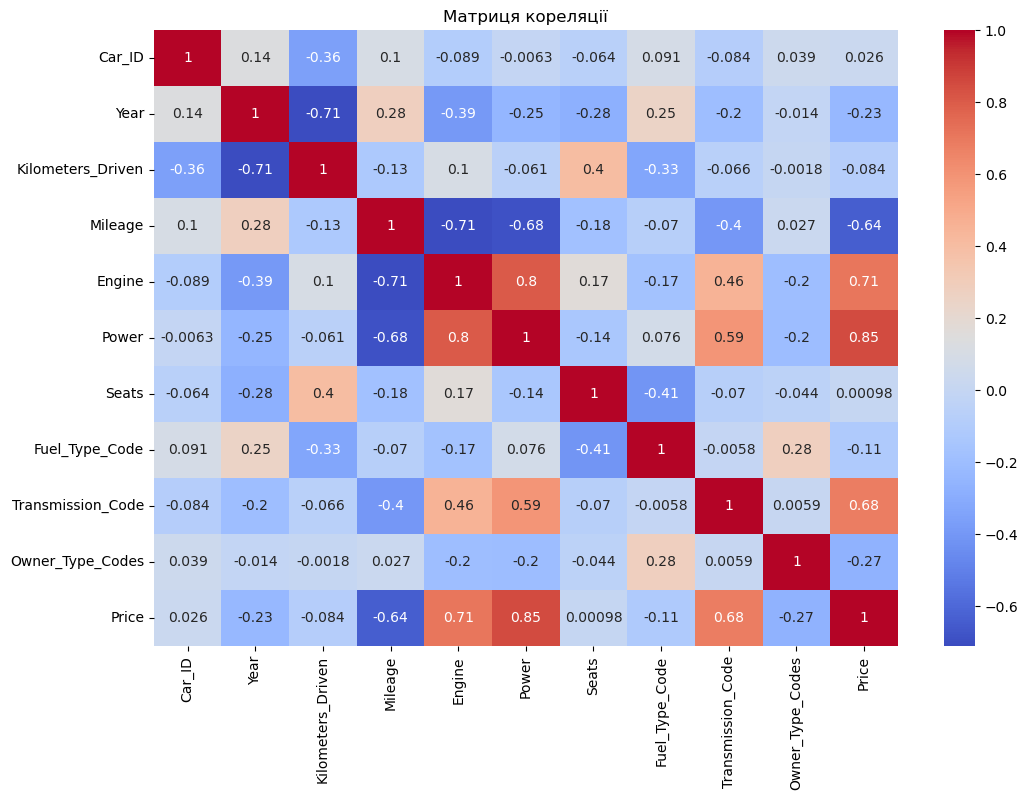

In [104]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Матриця кореляції')
plt.show()

In [105]:
correlation_matrix['Price'].sort_values(ascending=False)

Price                1.000000
Power                0.849137
Engine               0.710561
Transmission_Code    0.680731
Car_ID               0.025560
Seats                0.000979
Kilometers_Driven   -0.083951
Fuel_Type_Code      -0.110782
Year                -0.233769
Owner_Type_Codes    -0.265537
Mileage             -0.638404
Name: Price, dtype: float64

#### Висновок до завдання 5 

По кореляції з цільовою змінною (Price): спостерігається сильна позитивна кореляція з Power (0.84), Engine (0.71), Transmission_code (0.68)
Сильна негативна кореляція з Milleage (-0.64) та решта колонок мають слабкий зв'язок з цільовою змінною. 

В загальному можна спостерігати сильну позитивну кореляцію між іншими ознаками - наприклад Engine і Power (0.8), це має пояснення, оскільки більший двигун це більша потужність. Або Year і Kilometers_Driven (-0.71) - чим новіше авто тим менше пробіг.



**Завдання 6**. Тренуємо лінійну регресію.
0. Видаліть усі НЕчислові колонки з `X_train`, `X_test`, якщо ще цього не зробили.
1. Натренуйте лінійну регресую з `sklearn` на усіх числових даних тренувального набору `X_train`.
2. Зробіть передбачення на  `X_train`, `X_test`. Знайдіть і виведіть root mean squared error відхилення передбачення від справжніх значень цільової змінної.
3. Побудуйте графік розсіювання передбачень проти реальних даних цільової змінної для тренувального і тестувального наборів даних. Що можете сказати про якість моделі?

In [106]:
X_train_numeric = X_train.select_dtypes(include='number')
X_test_numeric = X_test.select_dtypes(include='number')

In [107]:
model = LinearRegression()
model.fit(X_train_numeric, y_train)

LinearRegression()

In [108]:
predictions_train = model.predict(X_train_numeric)
predictions_test = model.predict(X_test_numeric)

print('RMSE (тренувальні дані):', root_mean_squared_error(y_train, predictions_train))
print('RMSE (тестові дані):', root_mean_squared_error(y_test, predictions_test))

RMSE (тренувальні дані): 420447.81761804124
RMSE (тестові дані): 321061.2299075404


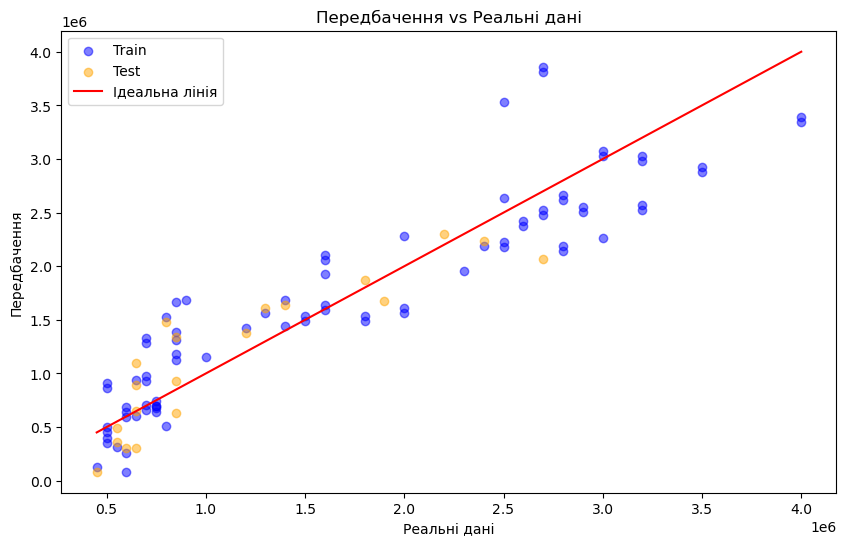

In [109]:
plt.figure(figsize=(10, 6))
plt.scatter(y_train, predictions_train, color='blue', alpha=0.5, label='Train')
plt.scatter(y_test, predictions_test, color='orange', alpha=0.5, label='Test')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], label='Ідеальна лінія', color='red')
plt.xlabel('Реальні дані')
plt.ylabel('Передбачення')
plt.title('Передбачення vs Реальні дані')
plt.legend()
plt.show()

#### Висновок завдання 6

Отримали наступні значення 
RMSE (тренувальні дані): ~ 420k рупій
RMSE (тестові дані): ~321k рупій

На графіку спостерігається розкид, чим дорожче автівка тим більше модель помиляється. Але в цілому точки слідують за "ідеальною" лінією, а отже загальну тенденцію модель ловить.

В цілому, модель треба було б покращити.

**Завдання 7**. Ми хочемо проаналізувати як впливає кожен чинник на цілову змінну. Для цього давайте промасштабуємо наші дані.
1. Зробіть масштабування незалежних змінних використовуючи `StandardScaler`. Тренуємо на тренувальних даних, а на тестувальних лише викликаємо `transform`.

2. Натренуйте модель на відмасштабованих даних і перегляньте коефіцієнти моделі. Які колонки є найвпливовішими на формування передбачення з точки зору коефіцієнтів? Проаналізуйте напрям дії найважливіших коефіцієнтів. Чи це логічно з точки зору значення відповідних змінних, що вони впливають на цільову змінну саме в напрямі збільшення / зменшення?

In [110]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

In [111]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

LinearRegression()

In [112]:
weights_df = pd.DataFrame({
    'feature': X_train_numeric.columns,
    'weight': model_scaled.coef_
}).sort_values('weight', ascending=False)

print(weights_df)

             feature         weight
5              Power  661989.491744
8  Transmission_Code  279936.957168
6              Seats   71985.402617
0             Car_ID   34839.440315
1               Year  -91653.327269
9   Owner_Type_Codes -112595.653542
4             Engine -141010.976671
2  Kilometers_Driven -179779.802472
7     Fuel_Type_Code -180363.557145
3            Mileage -192754.975380


#### Висновок по завданню 7 

Серед коефіцієнтів що мають позитивний вплив і тим самим збільшують ціну: Power зі значенням 661989 (чим потужніе авто тим воно дорожче), Transmission_Code - 279936 (певно тому що автомат завжди дорожче),  Seats - 71985 (більші авто дорожчі). Тут все насправді логічно, вплив на цільову змінну логічний.

Серед коефіцієнтів що мають негативний вплив (зменшують ціну): Mileage зі значенням -192754, Fuel_Type_Code (-180363), Kilometers_Driven (-179779). Тут теж все логічно, оскільки якщо великий пробіг, якщо авто на бензині це може зменшити вартісь автівки.

Щодо Engine зі значенням -14101, це виглядає дивно, оскільки на матриці кореляції ця фіча мала позитивну кореляцію з Вартістю.

**Завдання 8.** На тих самих відмасштабованих даних натренуйте модель з `statsmodels`. Виведіть звіт і проаналізуйте p-value коефіцієнтів. Які ознаки є стат значущими на рівні значущості 0.05? Напишіть їх список.

In [113]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_numeric.columns)
X_train_scaled_sm = sm.add_constant(X_train_scaled_df)
model_sm = sm.OLS(y_train.values, X_train_scaled_sm)
results_sm = model_sm.fit()
print(results_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     34.82
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.22e-23
Time:                        23:42:09   Log-Likelihood:                -1149.4
No. Observations:                  80   AIC:                             2321.
Df Residuals:                      69   BIC:                             2347.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   5.06e+0

Статистично значущі ознаки: Power (0.000), Transmission_Code (0.000), Fuel_Type_Code (0.007), Mileage (0.023). На межі маємо Owner_Type_Codes (0.051) та Kilometers_Driven (0.053).

**Завдання 9**. Натренуйте лінійну регресію з `statsmodels` тільки на ознаках, які виявлись стат. значущими в попередньому завданні. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared?

In [114]:
significant_features = ['Power', 'Transmission_Code', 'Fuel_Type_Code', 'Mileage']

X_train_significant = sm.add_constant(X_train_scaled_df[significant_features])
model_sm_significant = sm.OLS(y_train.values, X_train_significant)
results_sm_significant = model_sm_significant.fit()
print(results_sm_significant.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.805
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     77.42
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           7.36e-26
Time:                        23:42:10   Log-Likelihood:                -1156.0
No. Observations:                  80   AIC:                             2322.
Df Residuals:                      75   BIC:                             2334.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   5.27e+0

R-squared: стало 0.805 (було 0.835), показник зменшився на 0.03
Adj. R-squared: стало 0.795 (було 0.811), показник зменшився на 0.016

Було прибрано 6 ознак, тому R-squared впав, але падіння всього 3 відсотки. 
Бачимо що Mileage тепер 0.107 - ознака стала незначущою. Певно у попередній моделі на неї впливали інші ознаки (мультиколінеарність? Гадаю, те саме було і з Engine зі значенням -14101 в 7 завданні)

**Завдання 10**. Натренуйте лінійну регресію з `statsmodels` на усіх ознаках з масштабованого `X_train`, у яких p_value в завданні 8 менше за `0.25`. Ми таким чином помʼякшили критерій відбору ознак. Проаналізуйте показники моделі. Чи значно змінились R2 і Adj. R-squared порівняно з завданням 8? Яку модель з останніх 3х завдань ви б лишили для використання?

In [115]:
columns_less_sig = ['Power', 'Transmission_Code', 'Fuel_Type_Code', 'Mileage', 'Owner_Type_Codes', 'Kilometers_Driven', 'Engine']

X_train_less_sig = sm.add_constant(X_train_scaled_df[columns_less_sig])
model_sm_less_sig = sm.OLS(y_train.values, X_train_less_sig)
results_sm_less_sig = model_sm_less_sig.fit()
print(results_sm_less_sig.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.810
Method:                 Least Squares   F-statistic:                     49.06
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           6.59e-25
Time:                        23:42:10   Log-Likelihood:                -1151.3
No. Observations:                  80   AIC:                             2319.
Df Residuals:                      72   BIC:                             2338.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               1.68e+06   5.07e+0

R-squared: стало 0.827 (було 0.835 у завд. 8)
Adj. R-squared: стало 0.810 (було 0.811 у завд. 8)

Я б певно обрала модель з цього завдання (10), бо вона має R-squared на 0.008 менше ніж повна модель з 8 завдання (а в 9 на 0.03). Adj. R-squared у неї майже однаковий з моделлю завдання 8, а ознак набагато менше. 
Модель з 9 завдання була занадто спрощена, а повна модель з завдання 8 містила ознаки які не несли особливої ваги